In [2]:
import numpy as np

class Softmax:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

class Sigmoid:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        return 1 / (1 + np.exp(-x))
    
    def derivative(self, x):
        s = self.forward(x)
        return s * (1 - s)


class ReLU:
    # He initialization
    weight_init_factor = np.sqrt(2)

    def forward(self, x):
        return np.maximum(0, x)
    
    def derivative(self, x):
        return (x > 0).astype(float)

In [3]:
class Layer:
    def __init__(self, num_neurons: int, num_input_connections: int, activation_function, rng, alpha=0.05, beta_one=0.9, beta_two=0.999, epsilon = 1e-8):
        self.num_neurons = num_neurons
        self.activation_function = activation_function
        self.weights =  rng.standard_normal((num_input_connections, num_neurons)) * activation_function.weight_init_factor * np.sqrt(1/num_input_connections)
        self.biases = self.biases = rng.standard_normal(num_neurons) * 0.01
        self.prev_inputs = None
        self.z = None
        self.error_signals = None
        self.alpha = alpha


        # adam optimizer stuff
        self.ma_weight_signal = np.zeros((num_input_connections, num_neurons)) # moving average bias gradient signal for adam optimizer
        self.ma_bias_signal = np.zeros(num_neurons) # moving average weight gradient signal for adam optimizer
        self.update_steps = 0
        self.beta_one = beta_one
        self.ma_weight_signal_variance = np.zeros((num_input_connections, num_neurons))
        self.ma_bias_signal_variance = np.zeros(num_neurons)
        self.beta_two = beta_two
        self.epsilon = epsilon

    def forward(self, x) -> np.array:
        self.z = x @ self.weights + self.biases
        self.prev_inputs = x
        return self.activation_function.forward(self.z)

    def backward(self, error_signals) -> np.array:
        self.update_steps += 1

        # i didnt add a derivative to softmax cus im lazy, i didn't feel like spending the time figuring out the jacobians, just passing the loss for the next step all the way through
        if hasattr(self.activation_function, 'derivative'):
            dLdz = error_signals * self.activation_function.derivative(self.z)
        else:
            dLdz = error_signals
    
        batch_size = error_signals.shape[0]

        bias_gradient_signal = np.sum(dLdz, axis=0) / batch_size
        self.ma_bias_signal = (self.beta_one * self.ma_bias_signal) + (1 - self.beta_one) * bias_gradient_signal # first moment
        self.ma_bias_signal_variance = (self.beta_two * self.ma_bias_signal_variance) + (1 - self.beta_two) * bias_gradient_signal ** 2 # second moment
        mb = self.ma_bias_signal / (1 - self.beta_one ** self.update_steps) # bias correction
        vb = self.ma_bias_signal_variance / (1 - self.beta_two ** self.update_steps) # bias correction
        dB = mb / (np.sqrt(vb) + self.epsilon)

        weight_gradient_signal = (self.prev_inputs.T @ dLdz) / batch_size
        self.ma_weight_signal = ( (self.beta_one * self.ma_weight_signal) + (1 - self.beta_one) * weight_gradient_signal ) # first moment
        self.ma_weight_signal_variance = (self.beta_two * self.ma_weight_signal_variance) + (1 - self.beta_two) * weight_gradient_signal ** 2 # second moment
        mw = self.ma_weight_signal / (1 - self.beta_one ** self.update_steps) # bias correction
        vw = self.ma_weight_signal_variance / (1 - self.beta_two ** self.update_steps) # bias correction
        dW = mw / (np.sqrt(vw) + self.epsilon)

        error_signals = dLdz @ self.weights.T
        self.biases += -self.alpha * dB
        self.weights += -self.alpha * dW

        return error_signals


In [4]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = np.frombuffer(file.read(), dtype=np.uint8)
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            images = np.frombuffer(file.read(), dtype=np.uint8).reshape(size, rows, cols)
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from os.path import join
import struct

#
# Set file paths based on added MNIST Datasets
#
input_path = ''
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()


In [6]:
x_train = np.array([x.ravel() for x in x_train], dtype=np.float32) / 255.0
x_test = np.array([x.ravel() for x in x_test], dtype=np.float32) / 255.0

def to_one_hot(y, num_classes=10):
    if y.ndim == 1:
        one_hot = np.zeros((y.size, num_classes))
        one_hot[np.arange(y.size), y] = 1
        return one_hot
    return y
y_train_encoded = to_one_hot(y_train, 10)
y_test_encoded = to_one_hot(y_test, 10)

def get_batches(X, y, batch_size):
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    
    np.random.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        
        yield X[batch_indices], y[batch_indices]

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


Epoch 1/13 - Loss: 0.2915
Epoch 2/13 - Loss: 0.1218
Epoch 3/13 - Loss: 0.0814
Epoch 4/13 - Loss: 0.0591
Epoch 5/13 - Loss: 0.0449
Epoch 6/13 - Loss: 0.0336
Epoch 7/13 - Loss: 0.0266
Epoch 8/13 - Loss: 0.0202
Epoch 9/13 - Loss: 0.0158
Epoch 10/13 - Loss: 0.0123
Epoch 11/13 - Loss: 0.0112
Epoch 12/13 - Loss: 0.0093
Epoch 13/13 - Loss: 0.0074


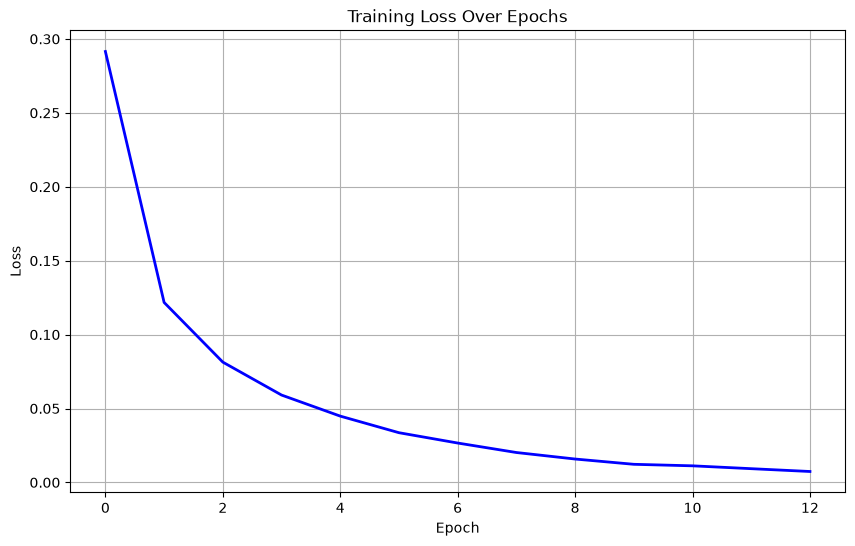

In [7]:
rng = np.random.default_rng(42)
layers = [
    Layer(num_neurons=256, num_input_connections=784, activation_function=ReLU(), rng=rng, alpha=0.001),
    Layer(num_neurons=10, num_input_connections=256, activation_function=Softmax(), rng=rng, alpha=0.001)
]

import matplotlib.pyplot as plt
loss_history = []
epochs = 13
batch_size = 80
eps = 1e-15
for epoch in range(epochs):
    running_loss = 0.0
    num_batches = 0
    
    for x_batch, y_batch in get_batches(x_train, y_train_encoded, batch_size):
        
        out = x_batch
        for layer in layers:
            out = layer.forward(out)

        out_clipped = np.clip(out, eps, 1 - eps)
        batch_loss = -np.sum(y_batch * np.log(out_clipped)) / x_batch.shape[0]
        running_loss += batch_loss
        num_batches += 1

        upstream_error = out - y_batch
        for layer in reversed(layers):
            upstream_error = layer.backward(upstream_error)

    epoch_loss = running_loss / num_batches
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f}")

# --- Plot Loss Curve ---
plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)


In [8]:
# Run test set evaluation
out = x_test
for layer in layers:
    out = layer.forward(out)

predictions = np.argmax(out, axis=1)
accuracy = np.mean(predictions == y_test)
print(f"test accuracy: {accuracy * 100:.2f}%")

test accuracy: 97.83%


In [ ]:
def save_model(layers, filepath="model_weights.npz"):
    model_data = {}
    for i, layer in enumerate(layers):
        model_data[f"w_{i}"] = layer.weights
        model_data[f"b_{i}"] = layer.biases

    np.savez_compressed(filepath, **model_data)


save_model(layers, "mnist_model.npz")

Model successfully saved to mnist_model.npz
